In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
assert os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] == "false"

import sys
sys.path.append('../')
sys.path.append('../../')

import ATLAS

import json, pickle
from glob import glob
from tqdm import tqdm

import numpy as np
from matplotlib import pyplot as plt

from functools import partial
import jax.numpy as jnp
import jax.random as jrandom

from ATLAS.utils import jit, jit_method, get_pulsar_timespan
from ATLAS.utils import jagged2padded
from ATLAS.signals.signals_utils import _timing_model_svd, get_fourier_design_matrix

import numpyro
import numpyro.distributions as dist

sim_path = '../../datasets/sim_NG15_01'
with open(sim_path+'/injected_params.json', 'r') as f:
    injected_params = json.load(f)

JAX 64-bit mode automatically enabled successfully.


/home/kyleg/miniforge3/envs/atlas/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from ATLAS.pulsar import load_pulsars
from ATLAS.data import PTA_Data

i = 10
npsrs = 2

par = sorted(glob(sim_path+'/par/*.par'))[i:i+npsrs]
tim = sorted(glob(sim_path+'/tim/*.tim'))[i:i+npsrs]

psrs = load_pulsars(par, tim, use_enterprise=True)

data = PTA_Data(psrs, fixed_res = False, marg_timing = False, 
                diag_white_cov = False, linear_timing = True)


libstempo not installed. PINT or libstempo are required to use par and tim files.
Loading pulsars...:   0%|          | 0/2 [00:00<?, ?it/s]

JAX 64-bit mode automatically enabled successfully.JAX 64-bit mode automatically enabled successfully.



libstempo not installed. PINT or libstempo are required to use par and tim files.
libstempo not installed. PINT or libstempo are required to use par and tim files.
Loading pulsars...: 100%|██████████| 2/2 [00:07<00:00,  3.81s/it]


In [5]:
M_other_labels[0]

array(['Offset', 'PX', 'ELONG', 'ELAT', 'PMELONG', 'PMELAT', 'F0', 'F1',
       'DMX_0001', 'DMX_0002', 'DMX_0003', 'DMX_0004', 'DMX_0005',
       'DMX_0006', 'DMX_0007', 'DMX_0008', 'DMX_0009', 'DMX_0010',
       'DMX_0011', 'DMX_0012', 'DMX_0013', 'DMX_0014', 'DMX_0015',
       'DMX_0016', 'DMX_0017', 'DMX_0018', 'DMX_0019', 'DMX_0020',
       'DMX_0021', 'DMX_0022', 'DMX_0023', 'DMX_0024', 'DMX_0025',
       'DMX_0026', 'JUMP1'], dtype='<U8')

In [ ]:
binary_params = ['PB', 'PBDOT', 'A1', 'A1DOT', 'T0', 'TASC', 'ECC', 'EDOT', 'OM', 'OMDOT', 
                 'EPS1', 'EPS2', 'SINI', 'M2', 'KIN', 'KOM', 'H3', 
                 'FB0', 'FB1', 'FB2', 'FB3', 'FB4', 'FB5']


M_full = [p.Mmat for p in psrs]
M_full_labels = [np.array(p.Mmat_labels) for p in psrs]

is_binary = []
for M in M_full_labels:
    b = jnp.array([(l in binary_params) for l in M])
    is_binary.append(b)

M_other = [M[:,~b] for M, b in zip(M_full, is_binary)]
U_other = [_timing_model_svd(M) for M in M_other]
M_other_labels = [M[~b] for M, b in zip(M_full_labels, is_binary)]

M_binary = [M[:,b] for M, b in zip(M_full, is_binary)]
M_binary_labels = [M[b] for M, b in zip(M_full_labels, is_binary)]

# Concatenate the un-normed binary timing model with the normed other timing model
M_comb = [jnp.concatenate([b, o], axis=1) for b, o in zip(M_binary, U_other)]
M_comb_labels = [np.concatenate([b, o]) for b, o in zip(M_binary_labels, M_other_labels)]

# Add the concatenated timing model to data
data.add_timing_design_matrix(M_comb)

In [9]:

from ATLAS.psd_functions import powerlaw, free_spectrum, hd_orf
from ATLAS.signals.factorized.base import Red, SuperSignal
from ATLAS.signals.correlated.base import Correlated
from ATLAS.nMatrix.base import WhiteCov
from ATLAS.signals import signals_utils as sutils
import ATLAS.utils as atlas_utils
import ATLAS.signals.factorized.utils as unc_utils
import ATLAS.signals.correlated.utils as cor_utils

## White Noise Model
wn_model = WhiteCov(data = data, stabilize_TNT = True)
wn_lower_bound, wn_upper_bound = wn_model.get_prior_bounds() #white noise prior bounds

## Red Noise Model
non_gwb_nfreqs = 30
gwb_nfreqs = 14
sig_unc = Red(name='unc',
            psd_function = partial(powerlaw),
            nfreqs=non_gwb_nfreqs,
            lower_bound_psd = jnp.array([-18, 0.]),
            upper_bound_psd = jnp.array([-11, 7.0]),
            data = data,
            use_pulsar_tspan = False)

# GWB model
sig_cor = Correlated(name='cor',
            psd_function = partial(powerlaw),
            orf_function = hd_orf,
            nfreqs=gwb_nfreqs,
            lower_bound_psd = jnp.array([-18., 0.]),
            upper_bound_psd = jnp.array([-11., 1.]),
            data = data)

# Combined model
sig = SuperSignal(signal_list = [sig_unc],#, sig_cor],
                signal_combination_string = "ltm|unc->unc",
                data=data)


Construncting the white noise cov matrix for J0610-2100: 100%|██████████| 2/2 [00:00<00:00,  3.57it/s]


In [42]:
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, init_to_value, init_to_uniform

from ATLAS.samplers.canetoadracing import MultiHMCGibbs

theta_wn_dist = dist.Uniform(wn_lower_bound, wn_upper_bound)
xs_dist = dist.Uniform(sig.model.lower_prior_lim_all, sig.model.upper_prior_lim_all)
z_a_dist = dist.Normal(0, 1).expand((sig.npsrs, sig.nmodes))
r_all = jnp.concatenate(data.raw_residuals)

def model():

    ######################################## White Noise ########################################
    # Declare the variables in the model
    theta_wn = numpyro.sample('theta_wn', theta_wn_dist)
    helpers_now = sig.get_helpers(reff = r_all, white_noise_params=theta_wn)
    
    ######################################## Red Noise ########################################
    # Declare the variables in the model
    xs = numpyro.sample('xs', xs_dist) #PSD params
    z_a = numpyro.sample('z_a', z_a_dist) #the reparam coefficients
    # evaluate the posterior
    lprob, coeff = sig.lnposterior_reparam(helpers = helpers_now, red_params = xs, z = z_a)
    numpyro.factor('lnpost', lprob + 0.5 * jnp.sum(z_a**2))
    
    numpyro.deterministic('tm_z', z_a[:,:sig.linear_timing_model_size])
    numpyro.deterministic('tm_coeff', coeff[:,:sig.linear_timing_model_size])


kernel = NUTS(model=model, max_tree_depth=12)

mcmc = MCMC(sampler=kernel, num_warmup=1000, num_samples=1000)

mcmc.run(jrandom.PRNGKey(170817))
samples = mcmc.get_samples()

samples.keys()

  0%|          | 0/2000 [00:00<?, ?it/s]

sample: 100%|██████████| 2000/2000 [03:19<00:00, 10.03it/s, 31 steps of size 1.25e-01. acc. prob=0.92]


dict_keys(['theta_wn', 'tm_coeff', 'tm_z', 'xs', 'z_a'])

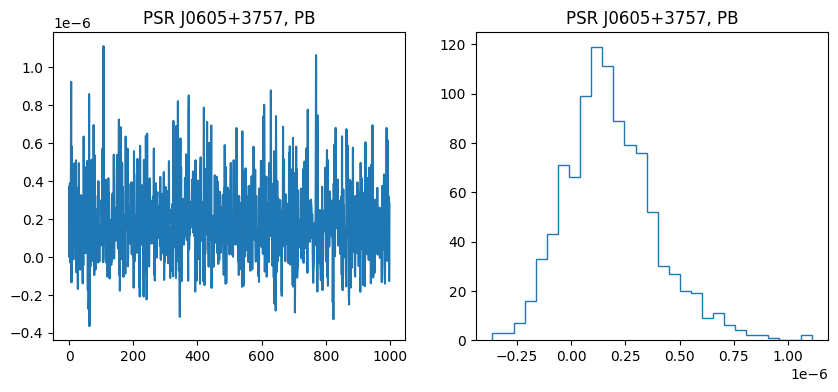

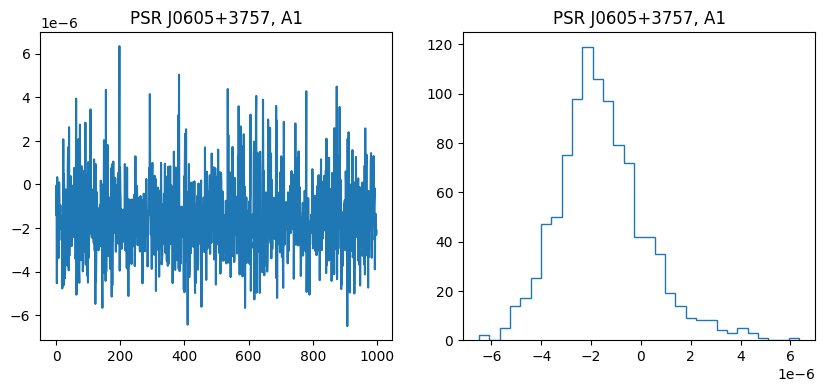

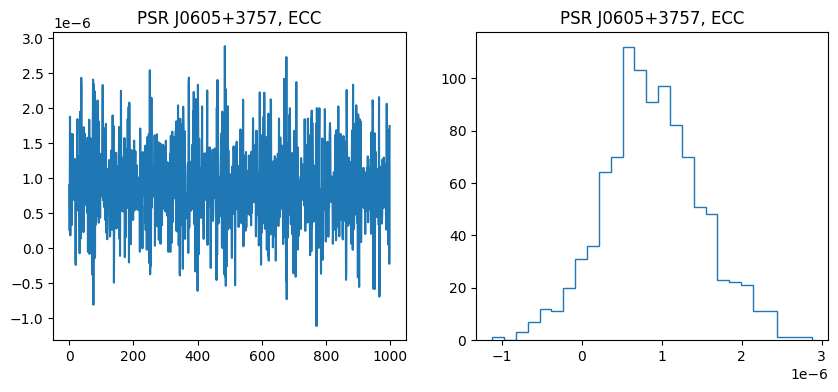

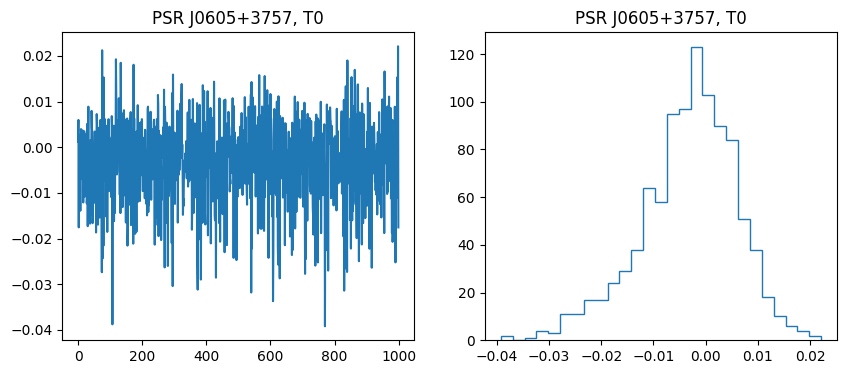

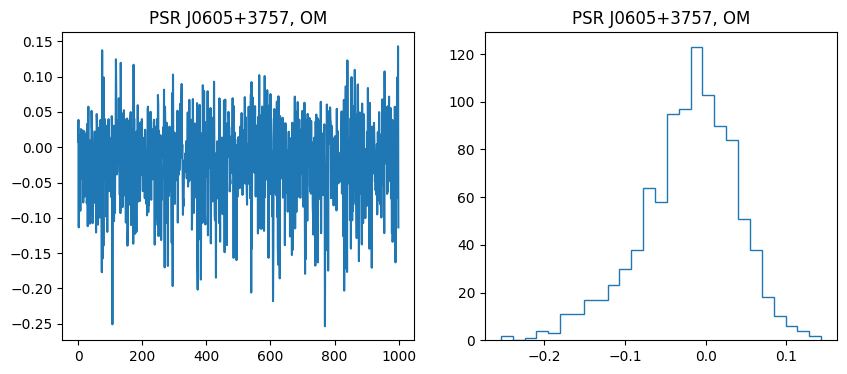

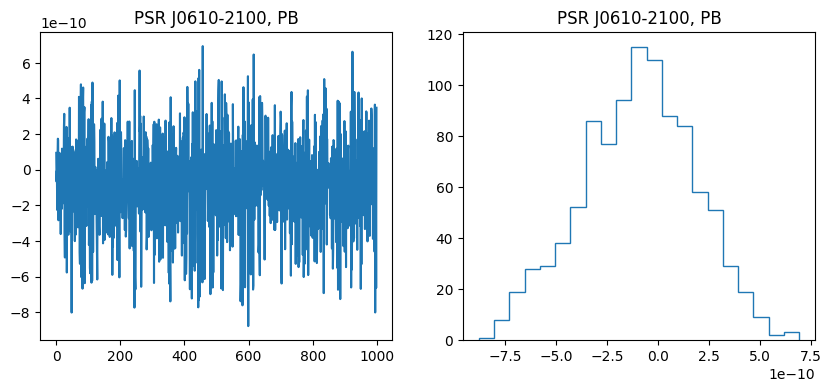

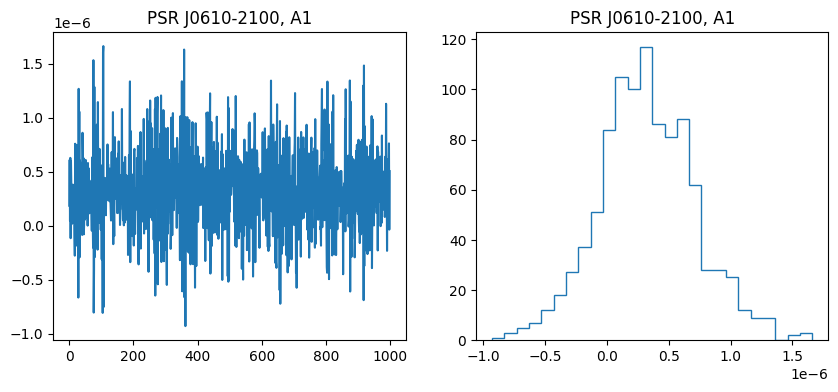

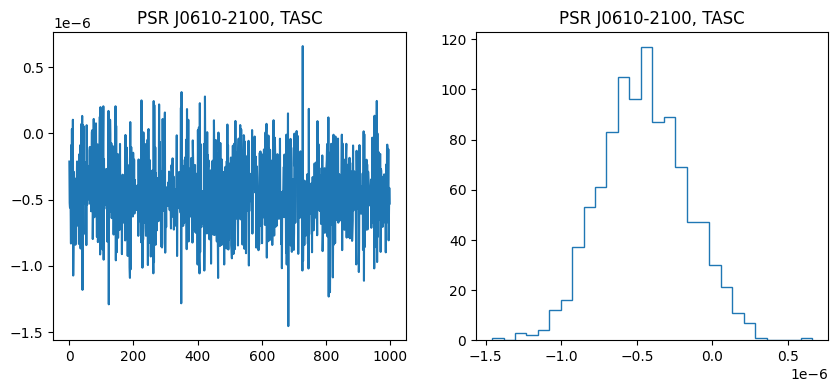

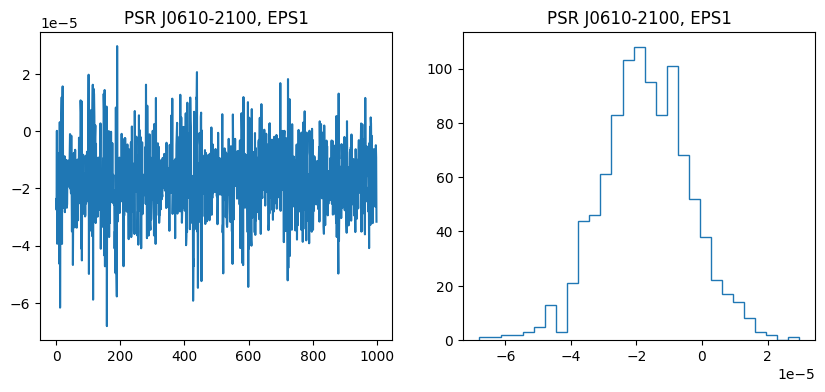

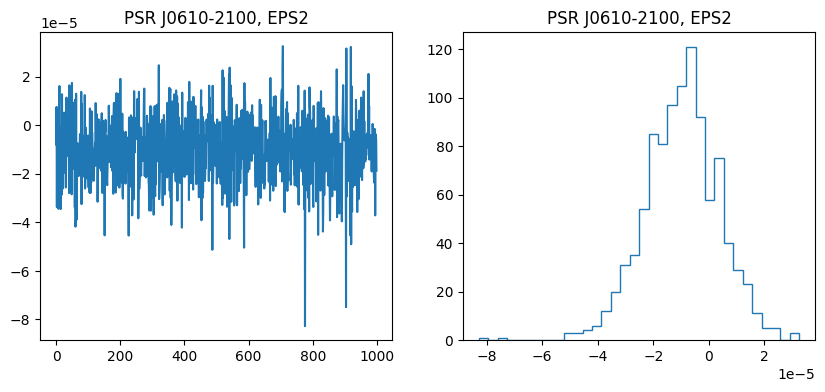

In [47]:
for i in range(npsrs):
    mb_labels = M_binary_labels[i]
    for j in range(len(mb_labels)):
        mb_label = mb_labels[j]
        chain = samples['tm_coeff'][:,i,j]

        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.plot(chain)
        plt.title(f'PSR {psrs[i].name}, {mb_label}')

        plt.subplot(1, 2, 2)
        plt.hist(chain, bins='auto', histtype='step')
        plt.title(f'PSR {psrs[i].name}, {mb_label}')
        plt.show()